In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Bulgaria Before and After 1989: Demographic and Health Trends

## Working research question
Are the trends in selected demographic and health indicators statistically different between the communist period and the post-communist period in Bulgaria?

## Introduction

This project explores whether selected demographic and health indicators in Bulgaria differ between the communist and post-communist periods.

The analysis focuses on a small set of long-run indicators that are available in a usable form across a broad time range. The goal is not to make a political judgement about the two periods, but to examine whether measurable demographic and health trends show clear differences before and after 1989.

## Research question and objectives

### Main research question
Are the trends in selected demographic and health indicators statistically different between the communist period and the post-communist period in Bulgaria?

### Objectives
- to prepare a clean working dataset for selected demographic and health indicators
- to compare the two periods using matched time windows where possible
- to examine whether the selected indicators show visible trend differences across the two periods
- to use more than one data source in a meaningful way
- indentifying and discussing important limitations in source coverage and comparability

## Data sources

### Main source
- World Bank: main long-run source for the selected indicators

### Supporting source
- National Statistical Institute (NSI), Bulgaria: used for population overlap and source comparison in the later period

### Notes
The World Bank data is used as the main backbone for the long-run comparison because it provides broad and consistent annual coverage.  
- NSI data is used as an independent national source for overlap comparison and contextual support where relevant.
- Eurostat: used as an official supporting source for infant mortality

The World Bank data is used as the main backbone for the long-run comparison because it provides broad and consistent annual coverage.

NSI data is used as an independent national source for overlap comparison and contextual support where relevant.

Eurostat is included as an additional official source for infant mortality, which helps strengthen the source base for that indicator.

## Scope and selected indicators

The project currently focuses on the following indicators:
- population, total
- life expectancy at birth
- fertility rate
- infant mortality

These indicators were chosen because they are central to demographic and health change and are available in usable long-run series.

## Period definition

The comparison is intended to use matched time windows for the two periods where possible.

A likely working approach is:
- communist period: 1960-1988
- post-communist period: 1990-2018

The year 1989 may be treated as a transition year and excluded from the formal comparison.

## Data preparation overview

The data preparation work is carried out in a separate notebook focused on inspection and cleaning.

That work includes:
- selecting the relevant World Bank indicators
- reshaping the World Bank data into a year-based format
- extracting, cleaning and merging NSI population data
- comparing overlapping population values between World Bank and NSI
- examination of Eurostat data

In [23]:
# managing datasets paths

current_dir = Path.cwd()

if current_dir.name == "bulgaria_before_after_1989":
    project_root = current_dir
elif (current_dir / "bulgaria_before_after_1989").exists():
    project_root = current_dir / "bulgaria_before_after_1989"
else:
    raise FileNotFoundError("Project root folder 'bulgaria_before_after_1989' was not found from the current working directory.")

raw_data_dir = project_root / "data" / "raw"
processed_data_dir = project_root / "data" / "processed"

world_bank_path = raw_data_dir / "API_BGR_DS2_en_csv_v2_12004.csv"
nsi_pop_2001_2011_path = raw_data_dir / "Pop_6.3_Census2011_EN.xlsx"
nsi_pop_2012_2021_path = raw_data_dir / "Pop_6.3_Census2021_EN.xlsx"

In [26]:
wb_population_clean_path = processed_data_dir / "wb_population_clean.csv"
nsi_population_combined_path = processed_data_dir / "nsi_population_combined.csv"

## Population overlap comparison between World Bank and NSI

Population is currently the strongest indicator in terms of visible two-source comparison in this project.  
To make the second source meaningful in the workflow, the cleaned NSI population data was compared with the World Bank population series for the overlapping years.

The aim of this comparison is not to decide which source is “correct”, but to examine whether the two series are close enough to support each other and to identify whether any systematic differences are present.

### Comparison approach

The World Bank population series was merged with the cleaned NSI population table using the common `year` column and keeping only overlapping years.

Two types of difference were then calculated:
- absolute difference
- relative difference in percent

The relative difference was calculated using the NSI value as the denominator, so the percentage shows how far the World Bank value is from the NSI value relative to the NSI series. NSI is used here as the national reference baseline for the overlapping years.

In [27]:
wb_population_clean_path = processed_data_dir / "wb_population_clean.csv"
nsi_population_combined_path = processed_data_dir / "nsi_population_combined.csv"

wb_population = pd.read_csv(wb_population_clean_path)
nsi_population_combined = pd.read_csv(nsi_population_combined_path)

wb_population.head(), nsi_population_combined.head()

(   year  population_total_wb
 0  1960            7867374.0
 1  1961            7943118.0
 2  1962            8012946.0
 3  1963            8078145.0
 4  1964            8144340.0,
    year  population_total_nsi
 0  2001               7868815
 1  2002               7805506
 2  2003               7745147
 3  2004               7688573
 4  2005               7629371)

In [29]:
population_comparison = pd.merge(
    wb_population,
    nsi_population_combined,
    on="year",
    how="inner"
)

population_comparison["absolute_difference"] = (
    population_comparison["population_total_wb"] - population_comparison["population_total_nsi"]
)

population_comparison["relative_difference_pct"] = (
    population_comparison["absolute_difference"] / population_comparison["population_total_nsi"]
) * 100

population_comparison.head()

,year,population_total_wb,population_total_nsi,absolute_difference,relative_difference_pct
0,2001,8009142.0,7868815,140327.0,1.783331
1,2002,7837161.0,7805506,31655.0,0.405547
2,2003,7775327.0,7745147,30180.0,0.389663
3,2004,7716860.0,7688573,28287.0,0.367910
4,2005,7658972.0,7629371,29601.0,0.387987


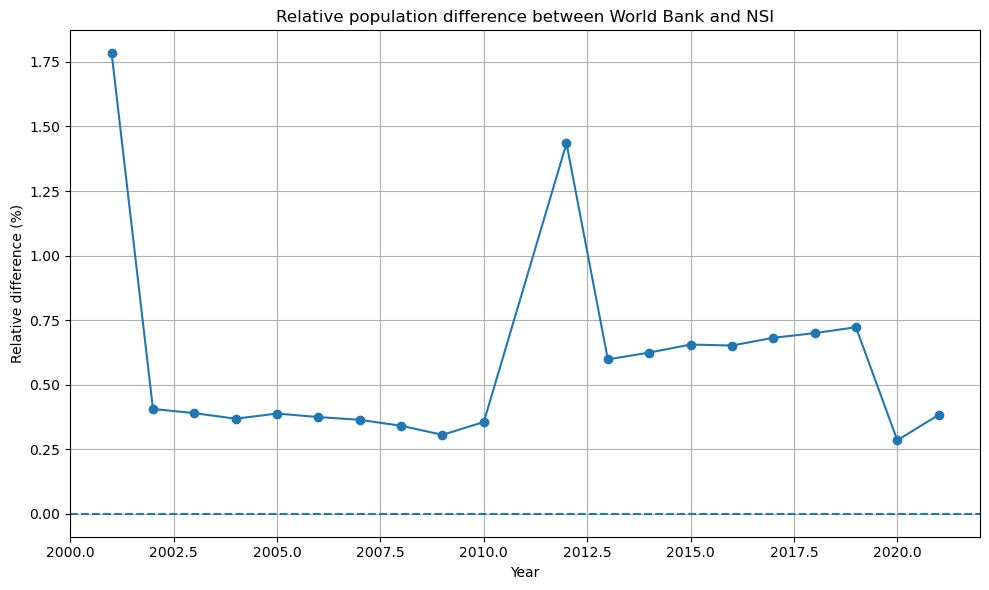

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    population_comparison["year"],
    population_comparison["relative_difference_pct"],
    marker="o"
)

plt.axhline(y=0, linestyle="--")
plt.title("Relative population difference between World Bank and NSI")
plt.xlabel("Year")
plt.ylabel("Relative difference (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

The calculated differences suggest that the two series are broadly consistent, while still showing small non-zero discrepancies.

Observed differences are likely related to revisions, update timing, or harmonization practices rather than to a completely different demographic picture.

## Exploratory analysis plan

The exploratory stage of the analysis will focus on:
- long-term trend plots for the selected indicators
- comparisons between the two historical periods
- overlap comparison between different sources where available
- summary statistics for the selected time windows

## Statistical analysis plan

The statistical part of the project is expected to include:
- descriptive statistics
- comparison of matched periods
- confidence intervals
- hypothesis testing for selected indicators

The exact tests will depend on the final structure and coverage of the cleaned datasets.

## Limitations

Some limitations are already visible:
- not all indicators are equally strong across all sources
- NSI coverage is more limited historically for some variables
- different sources may reflect slightly different revision practices or harmonization methods
- overlap comparisons may show small but non-zero differences between sources

## Conclusion

This section will summarize the main findings after the final comparative and statistical analysis is completed.

## References